# Proyecto I: Reconocimiento de comandos de voz

Curso de Inteligencia Artificial, Instituto Tecnológico de Costa Rica.

Notebook único del proyecto. Funciona en Google Colab y en escritorio.

## 0. Configuración

Constantes del **contrato de entrada** (`docs/contrato_entrada.md`). Si alguna cambia, la app móvil tiene que cambiar igual.

In [19]:
import os, sys, math, wave, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules

# --- Rutas ---
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_TAR = Path("/content/drive/MyDrive/ProyectoIA_ComandosDeVoz/archive.tar")   # los 10 comandos + listas
    DATA_DIR = Path("/content/archive")   # se extrae aquí en la celda 0.1
    OUT_DIR  = Path("/content/drive/MyDrive/ProyectoIA_ComandosDeVoz/resultados")
    CACHE_DIR = Path("/content/cache")   # los .pt (~620 MB) van al disco temporal de Colab, no al Drive
else:
    # Escritorio: carpeta con los audios (variable DATA_DIR o la ruta por defecto)
    DATA_DIR = Path(os.environ.get("DATA_DIR", Path.home() / "Downloads" / "archive"))
    OUT_DIR  = Path.cwd().parent / "resultados" if Path.cwd().name == "notebooks" else Path.cwd() / "resultados"
    CACHE_DIR = OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# --- Comandos ---
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABEL_TO_IDX = {c: i for i, c in enumerate(COMMANDS)}

# --- Contrato de entrada ---
SAMPLE_RATE = 16_000            # Hz
NUM_SAMPLES = SAMPLE_RATE * 1   # 1 segundo
N_FFT       = 480               # ventana de 30 ms
WIN_LENGTH  = 480
HOP_LENGTH  = 160               # salto de 10 ms
N_MELS      = 40
N_FRAMES    = NUM_SAMPLES // HOP_LENGTH + 1   # 101 columnas de tiempo
F_MIN, F_MAX = 20.0, 8_000.0
LOG_EPS     = 1e-6

# --- División ---
SPLITS = ["train", "val", "test"]

# --- Semillas ---
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

print("Colab:", IN_COLAB)
print("Datos:", DATA_DIR, "| existe:", DATA_DIR.exists())
print("Resultados:", OUT_DIR)

Colab: False
Datos: C:\Users\jenki\Downloads\archive | existe: True
Resultados: c:\Users\jenki\Desktop\IA\resultados


### 0.1 Copiar el dataset a Colab (solo Colab)

Leer 38 mil audios sueltos desde Google Drive es muy lento. Por eso el dataset (solo los 10 comandos y las listas) está en Drive como **un solo archivo** `archive.tar`. Esta celda lo copia al disco temporal de Colab y lo extrae, lo que tarda un par de minutos. Si ya se extrajo en esta sesión, no se repite.

En escritorio esta celda no hace nada: se usan los audios de `DATA_DIR`.

In [20]:
import shutil, tarfile

if IN_COLAB and not (DATA_DIR / "testing_list.txt").exists():
    local_tar = Path("/content/archive.tar")
    print("Copiando archive.tar desde Drive...")
    shutil.copy(DATA_TAR, local_tar)
    print("Extrayendo...")
    with tarfile.open(local_tar) as tar:
        tar.extractall("/content", filter="data")   # crea /content/archive
    local_tar.unlink()   # libera espacio en el disco de Colab

print("Datos listos en:", DATA_DIR, "| existe:", DATA_DIR.exists())


Datos listos en: C:\Users\jenki\Downloads\archive | existe: True


## 1. Datos y preprocesamiento

### 1.1 Filtrar el dataset a los 10 comandos

Speech Commands v0.02 trae 35 palabras más ruido de fondo. Solo se usan las 10 carpetas de los comandos.

In [21]:
rows = []
for c in COMMANDS:
    for p in sorted((DATA_DIR / c).glob("*.wav")):
        rows.append({"path": f"{c}/{p.name}", "label": c, "label_idx": LABEL_TO_IDX[c],
                     "speaker": p.name.split("_nohash_")[0]})
df = pd.DataFrame(rows)

# Si falta algún comando (por ejemplo, la subida a Drive no terminó), avisar de una vez
por_comando = df["label"].value_counts().reindex(COMMANDS, fill_value=0)
faltan = list(por_comando[por_comando == 0].index)
assert not faltan, f"No hay audios de: {faltan}. Revisa que esas carpetas estén completas en {DATA_DIR}"

print(f"{len(df)} audios de {len(COMMANDS)} comandos")
df.head()

38546 audios de 10 comandos


,path,label,label_idx,speaker
0,yes/004ae714_nohash_0.wav,yes,0,004ae714
1,yes/004ae714_nohash_1.wav,yes,0,004ae714
2,yes/00970ce1_nohash_0.wav,yes,0,00970ce1
3,yes/00f0204f_nohash_0.wav,yes,0,00f0204f
4,yes/00f0204f_nohash_1.wav,yes,0,00f0204f


### 1.2 División con las listas oficiales

El dataset trae dos listas: `validation_list.txt` y `testing_list.txt`. Los audios que no aparecen en ninguna van a entrenamiento. Las listas se construyeron asignando cada **hablante** a un solo conjunto, así una misma voz no aparece en dos conjuntos y el modelo no se evalúa con personas que ya escuchó al entrenar.

In [22]:
def read_list(name):
    return set((DATA_DIR / name).read_text().split())

val_files  = read_list("validation_list.txt")
test_files = read_list("testing_list.txt")

df["split"] = "train"
df.loc[df["path"].isin(val_files),  "split"] = "val"
df.loc[df["path"].isin(test_files), "split"] = "test"

# Verificación: ningún hablante en más de un conjunto
repetidos = df.groupby("speaker")["split"].nunique()
print("Hablantes en más de un conjunto:", int((repetidos > 1).sum()))

resumen = pd.DataFrame({
    "hablantes": df.groupby("split")["speaker"].nunique(),
    "audios": df["split"].value_counts(),
}).reindex(SPLITS)
resumen["% audios"] = (100 * resumen["audios"] / len(df)).round(1)
display(resumen)

df.to_csv(OUT_DIR / "splits.csv", index=False)
print("Guardado:", OUT_DIR / "splits.csv")

Hablantes en más de un conjunto: 0


,hablantes,audios,% audios
split,,,
train,2008,30769,79.8
val,245,3703,9.6
test,239,4074,10.6


Guardado: c:\Users\jenki\Desktop\IA\resultados\splits.csv


### 1.3 Balance de clases

split,train,val,test,total
label,,,,
yes,3228,397,419,4044
no,3130,406,405,3941
up,2948,350,425,3723
down,3134,377,406,3917
left,3037,352,412,3801
right,3019,363,396,3778
on,3086,363,396,3845
off,2970,373,402,3745
stop,3111,350,411,3872


Porcentaje de cada comando dentro de su conjunto (ideal 10 %):
  mín 9.5 %  |  máx 11.0 %


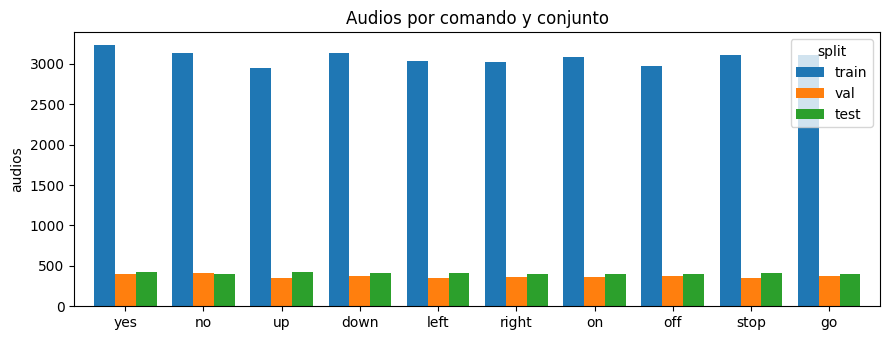

In [23]:
balance = pd.crosstab(df["label"], df["split"]).reindex(index=COMMANDS, columns=SPLITS)
display(balance.assign(total=balance.sum(axis=1)))

pct = 100 * balance / balance.sum()
print("Porcentaje de cada comando dentro de su conjunto (ideal 10 %):")
print(f"  mín {pct.values.min():.1f} %  |  máx {pct.values.max():.1f} %")

ax = balance.plot.bar(figsize=(9, 3.5), width=0.8)
ax.set_xlabel(""); ax.set_ylabel("audios"); ax.set_title("Audios por comando y conjunto")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(OUT_DIR / "balance_clases.png", dpi=150); plt.show()

### 1.4 Dataset crudo: audio → espectrograma log-mel

Pasos del contrato de entrada:

1. Leer WAV PCM 16 bits mono a 16 kHz y pasar a float32 en [-1, 1] (`int16 / 32768`).
2. Rellenar con ceros al final o recortar a 16 000 muestras (1 s).
3. STFT con ventana de Hann de 480 muestras, salto de 160, `center=True`, relleno *reflect*.
4. Potencia `|STFT|²`.
5. Banco de 40 filtros mel triangulares (escala HTK, 20–8000 Hz, sin normalización).
6. `log(mel + 1e-6)`.

Resultado: una matriz de **40 × 101** por audio.

In [24]:
def load_wav(path):
    with wave.open(str(path), "rb") as f:
        assert f.getnchannels() == 1 and f.getsampwidth() == 2 and f.getframerate() == SAMPLE_RATE, path
        pcm = np.frombuffer(f.readframes(f.getnframes()), dtype="<i2")
    return torch.from_numpy(pcm.astype(np.float32) / 32768.0)

def fix_length(wav, n=NUM_SAMPLES):
    return wav[:n] if wav.numel() >= n else torch.nn.functional.pad(wav, (0, n - wav.numel()))

def hz_to_mel(f): return 2595.0 * math.log10(1.0 + f / 700.0)
def mel_to_hz(m): return 700.0 * (10.0 ** (m / 2595.0) - 1.0)

def mel_filterbank(n_freqs=N_FFT // 2 + 1, n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX, sr=SAMPLE_RATE):
    all_freqs = torch.linspace(0, sr // 2, n_freqs, dtype=torch.float64)
    f_pts = mel_to_hz(torch.linspace(hz_to_mel(f_min), hz_to_mel(f_max), n_mels + 2, dtype=torch.float64))
    f_diff = f_pts[1:] - f_pts[:-1]
    slopes = f_pts[None, :] - all_freqs[:, None]
    down = -slopes[:, :-2] / f_diff[:-1]
    up   =  slopes[:, 2:]  / f_diff[1:]
    return torch.clamp(torch.minimum(down, up), min=0.0).float()   # (n_freqs, n_mels)

MEL_FB = mel_filterbank()
WINDOW = torch.hann_window(WIN_LENGTH)

def log_mel(wav):
    spec = torch.stft(wav, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, window=WINDOW,
                      center=True, pad_mode="reflect", return_complex=True)
    mel = MEL_FB.T @ (spec.abs() ** 2)
    return torch.log(mel + LOG_EPS)   # (40, 101) para un audio, o (B, 40, 101) para un lote de B audios

def audio_to_logmel(path):
    return log_mel(fix_length(load_wav(path)))

print("Forma:", tuple(audio_to_logmel(DATA_DIR / df["path"].iloc[0]).shape))

Forma: (40, 101)


Se calcula el log-mel de todos los audios y se guarda un archivo por conjunto (`raw_train.pt`, `raw_val.pt`, `raw_test.pt`) con `X` de forma `(N, 40, 101)` e `y` de forma `(N,)`. Si los archivos ya existen se cargan en vez de recalcular.

Para que sea rápido con pocos recursos:
- los audios se leen **en paralelo** (varios a la vez), porque leer archivos desde Drive o Kaggle es lo más lento;
- los espectrogramas se calculan **en lotes de 1000 audios** con una sola llamada a `torch.stft`, en vez de uno por uno.

El resultado es idéntico al de procesar cada audio por separado, y la memoria usada es solo la de un lote a la vez.

In [25]:
CONTRATO = {"sample_rate": SAMPLE_RATE, "num_samples": NUM_SAMPLES, "n_fft": N_FFT, "win_length": WIN_LENGTH,
            "hop_length": HOP_LENGTH, "n_mels": N_MELS, "f_min": F_MIN, "f_max": F_MAX, "log_eps": LOG_EPS}

from concurrent.futures import ThreadPoolExecutor

LOTE = 1000      # audios por lote: más grande = más rápido pero más memoria
HILOS = 16       # archivos leídos al mismo tiempo

def load_fixed(rel):
    return fix_length(load_wav(DATA_DIR / rel))

def build_split(split):
    archivo = CACHE_DIR / f"raw_{split}.pt"
    sub = df[df.split == split]
    if archivo.exists():
        d = torch.load(archivo)
        # Solo se reutiliza si se hizo con el mismo contrato y los mismos audios
        if d.get("contrato") == CONTRATO and d.get("paths") == list(sub["path"]):
            print(f"{split}: cargado de {archivo.name}")
            return d["X"], d["y"]
        print(f"{split}: el archivo guardado no coincide con los datos actuales, se recalcula")
    paths = list(sub["path"])
    X = torch.empty((len(paths), N_MELS, N_FRAMES))
    with ThreadPoolExecutor(HILOS) as pool:
        for inicio in range(0, len(paths), LOTE):
            ondas = torch.stack(list(pool.map(load_fixed, paths[inicio:inicio + LOTE])))   # (lote, 16000)
            X[inicio:inicio + len(ondas)] = log_mel(ondas)                                  # (lote, 40, 101)
            print(f"  {split}: {inicio + len(ondas)}/{len(paths)}", end="\r")
    y = torch.tensor(sub["label_idx"].to_numpy(), dtype=torch.int64)
    torch.save({"X": X, "y": y, "paths": list(sub["path"]), "contrato": CONTRATO}, archivo)
    print(f"{split}: {tuple(X.shape)} → {archivo.name}")
    return X, y

raw = {s: build_split(s) for s in SPLITS}

train: cargado de raw_train.pt
val: cargado de raw_val.pt
test: cargado de raw_test.pt


### 1.5 Ejemplos de espectrogramas (referencia)

Cinco espectrogramas del conjunto de entrenamiento, uno por comando, guardados como PNG en `resultados/ejemplos_espectrogramas/`. Son solo para ver cómo luce cada imagen; el modelo usa los números de los `.pt`, no estos PNG.

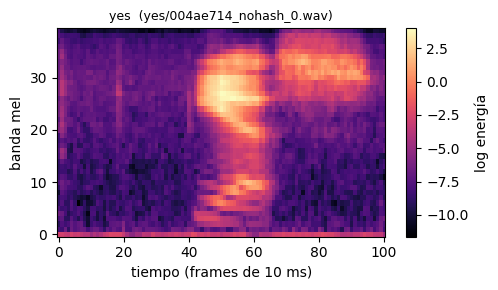

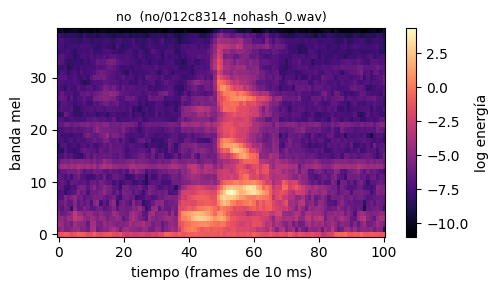

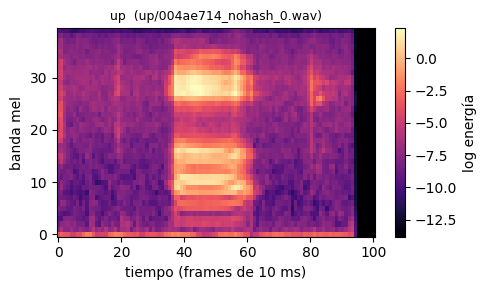

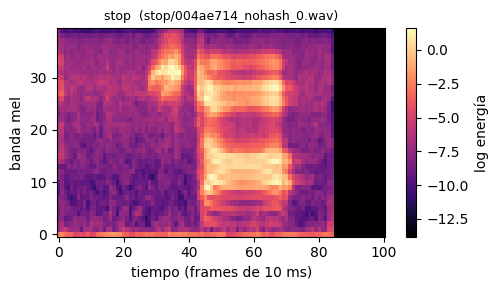

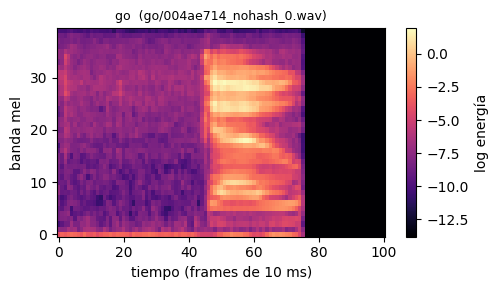

Guardados en: c:\Users\jenki\Desktop\IA\resultados\ejemplos_espectrogramas


In [26]:
EJEMPLOS_DIR = OUT_DIR / "ejemplos_espectrogramas"
EJEMPLOS_DIR.mkdir(exist_ok=True)

X_train, y_train = raw["train"]
train_paths = df[df.split == "train"]["path"].tolist()   # mismo orden que X_train

for c in ["yes", "no", "up", "stop", "go"]:
    i = y_train.tolist().index(LABEL_TO_IDX[c])            # primer audio de ese comando
    fig, ax = plt.subplots(figsize=(5, 3))
    im = ax.imshow(X_train[i], origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"{c}  ({train_paths[i]})", fontsize=9)
    ax.set_xlabel("tiempo (frames de 10 ms)"); ax.set_ylabel("banda mel")
    fig.colorbar(im, ax=ax, label="log energía")
    fig.tight_layout()
    fig.savefig(EJEMPLOS_DIR / f"{c}.png", dpi=150)
    plt.show()

print("Guardados en:", EJEMPLOS_DIR)

### 1.6 Dataset aumentado (SpecAugment)

**Técnica elegida.** SpecAugment (Park et al., 2019) modifica directamente el espectrograma log-mel, que es nuestra entrada, como si fuera una imagen. Propone tres deformaciones: *time warping*, *frequency masking* y *time masking*. Se usan las dos máscaras, sin time warping:

- **Frequency masking:** tapa franjas de bandas mel consecutivas. Obliga al modelo a no depender de unas pocas frecuencias (por ejemplo, si el micrófono del celular capta mal los graves).
- **Time masking:** tapa franjas de frames consecutivos. Obliga al modelo a reconocer la palabra aunque se pierda un pedazo (un golpe, un corte, ruido).

**Por qué esta combinación.** En la Tabla 6 del artículo se desactiva cada deformación por separado y se mide el error (WER en *test-other*):

| Configuración | Error |
|---|---|
| Las tres deformaciones | 10.0 % |
| **Sin time warping (frequency + time masking)** | **10.1 %** |
| Sin time masking | 10.9 % |
| Sin frequency masking | 11.0 % |

Sin time warping el error prácticamente no cambia (10.0 % → 10.1 %), mientras que sin cualquiera de las dos máscaras empeora. Los autores indican además que el time warping es la deformación más costosa y menos influyente, y la primera que debe quitarse con recursos limitados.

**Parámetros.** Las políticas del artículo se diseñaron para 80 bandas mel y frases de varios segundos. Nuestra entrada tiene 40 bandas y 101 frames (1 s), y una palabra ocupa solo unos 40–60 frames. Se adapta la política *Switchboard mild* (SM):

| Parámetro | Artículo (SM) | Este proyecto | Motivo |
|---|---|---|---|
| F (ancho máx. máscara de frecuencia) | 15 de 80 bandas | 7 de 40 bandas | Misma proporción (~19 %) |
| m_F (máscaras de frecuencia) | 2 | 2 | Igual |
| T (ancho máx. máscara de tiempo) | 70 frames, máx. 20 % | 12 frames (120 ms) | La palabra es corta; máscaras más anchas podrían borrarla completa |
| m_T (máscaras de tiempo) | 2 | 2 | Igual |

El ancho de cada máscara se elige al azar entre 0 y el máximo, y su posición también, como en el artículo.

**Valor de la máscara.** El artículo pone las zonas tapadas en 0 porque sus espectrogramas tienen media cero, es decir, las rellena con la media. Nuestro log-mel no está normalizado, así que se rellenan con **la media de cada espectrograma**, que es equivalente.

**Dataset aumentado.** Es igual al crudo, excepto el conjunto de entrenamiento: contiene los 30 769 espectrogramas originales **más una copia aumentada de cada uno** (61 538 en total). Validación y prueba son los mismos del crudo, sin aumentar, para que los dos datasets se evalúen igual. Las copias se generan con semilla fija, así que el dataset es reproducible.

**Qué esperar.** El artículo observa que la aumentación convierte un problema de sobreajuste en uno de subajuste: la pérdida en entrenamiento queda más alta que sin aumentación. Hay que tenerlo en cuenta al analizar las curvas en la Fase 3.

In [27]:
# Parámetros adaptados de la política SM del artículo a 40 bandas × 101 frames
FREQ_MASK_F = 7    # ancho máximo de cada máscara de frecuencia (bandas mel)
FREQ_MASKS  = 2    # número de máscaras de frecuencia (m_F)
TIME_MASK_T = 12   # ancho máximo de cada máscara de tiempo (frames de 10 ms)
TIME_MASKS  = 2    # número de máscaras de tiempo (m_T)

def freq_mask(spec, F=FREQ_MASK_F, m=FREQ_MASKS):
    """Tapa m franjas de bandas mel consecutivas, cada una de ancho al azar entre 0 y F."""
    spec = spec.clone()
    valor = spec.mean()
    n_mels = spec.shape[0]
    for _ in range(m):
        f  = int(torch.randint(0, F + 1, (1,)))
        f0 = int(torch.randint(0, n_mels - f + 1, (1,)))
        spec[f0:f0 + f, :] = valor
    return spec

def time_mask(spec, T=TIME_MASK_T, m=TIME_MASKS):
    """Tapa m franjas de frames consecutivos, cada una de ancho al azar entre 0 y T."""
    spec = spec.clone()
    valor = spec.mean()
    n_frames = spec.shape[1]
    for _ in range(m):
        t  = int(torch.randint(0, T + 1, (1,)))
        t0 = int(torch.randint(0, n_frames - t + 1, (1,)))
        spec[:, t0:t0 + t] = valor
    return spec

def spec_augment(spec):
    """SpecAugment sin time warping: máscaras de frecuencia y de tiempo. spec: (40, 101)."""
    return time_mask(freq_mask(spec))

**Generar y guardar el dataset aumentado.** Se crea `aug_train.pt` con los originales seguidos de sus copias aumentadas. Igual que con el crudo, si el archivo ya existe y se hizo con el mismo contrato, los mismos audios y los mismos parámetros, se carga en vez de recalcular.

Después se arman los dos datasets que usará la Fase 3: `DATASETS["crudo"]` y `DATASETS["aumentado"]`. Cada ejemplo se entrega con forma `(1, 40, 101)`: un canal, como una imagen en escala de grises.

In [28]:
from torch.utils.data import Dataset

AUMENTACION = {"freq_mask_F": FREQ_MASK_F, "freq_masks": FREQ_MASKS,
               "time_mask_T": TIME_MASK_T, "time_masks": TIME_MASKS, "seed": SEED}

def build_augmented_train():
    archivo = CACHE_DIR / "aug_train.pt"
    X, y = raw["train"]
    paths = list(df[df.split == "train"]["path"])
    if archivo.exists():
        d = torch.load(archivo)
        if d.get("contrato") == CONTRATO and d.get("aumentacion") == AUMENTACION and d.get("paths") == paths:
            print(f"train aumentado: cargado de {archivo.name}")
            return d["X"], d["y"]
        print("train aumentado: el archivo guardado no coincide, se recalcula")
    set_seed()   # mismas máscaras cada vez que se genera
    X_aug = torch.stack([spec_augment(x) for x in X])
    X_total = torch.cat([X, X_aug])   # originales + copias aumentadas
    y_total = torch.cat([y, y])
    torch.save({"X": X_total, "y": y_total, "paths": paths, "contrato": CONTRATO, "aumentacion": AUMENTACION}, archivo)
    print(f"train aumentado: {tuple(X_total.shape)} → {archivo.name}")
    return X_total, y_total

class SpectrogramDataset(Dataset):
    """Espectrogramas X (N, 40, 101) con etiquetas y. Entrega cada ejemplo como (1, 40, 101)."""
    def __init__(self, X, y):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i].unsqueeze(0), self.y[i]

aug_train = build_augmented_train()

DATASETS = {
    "crudo": {s: SpectrogramDataset(*raw[s]) for s in SPLITS},
    "aumentado": {
        "train": SpectrogramDataset(*aug_train),   # originales + copias aumentadas
        "val":   SpectrogramDataset(*raw["val"]),  # sin aumentar
        "test":  SpectrogramDataset(*raw["test"]), # sin aumentar
    },
}

for nombre, d in DATASETS.items():
    print(f"{nombre:>9}: " + " | ".join(f"{s} {len(d[s])}" for s in SPLITS))

train aumentado: cargado de aug_train.pt
    crudo: train 30769 | val 3703 | test 4074
aumentado: train 61538 | val 3703 | test 4074


**Verificación y ejemplo visual.** Se comprueba que el train aumentado contiene los originales intactos más copias distintas, que validación y prueba son iguales en los dos datasets, y se guarda una figura con el efecto de cada máscara en `resultados/ejemplos_aumentacion.png`.

Copias distintas de su original: 100.0 %


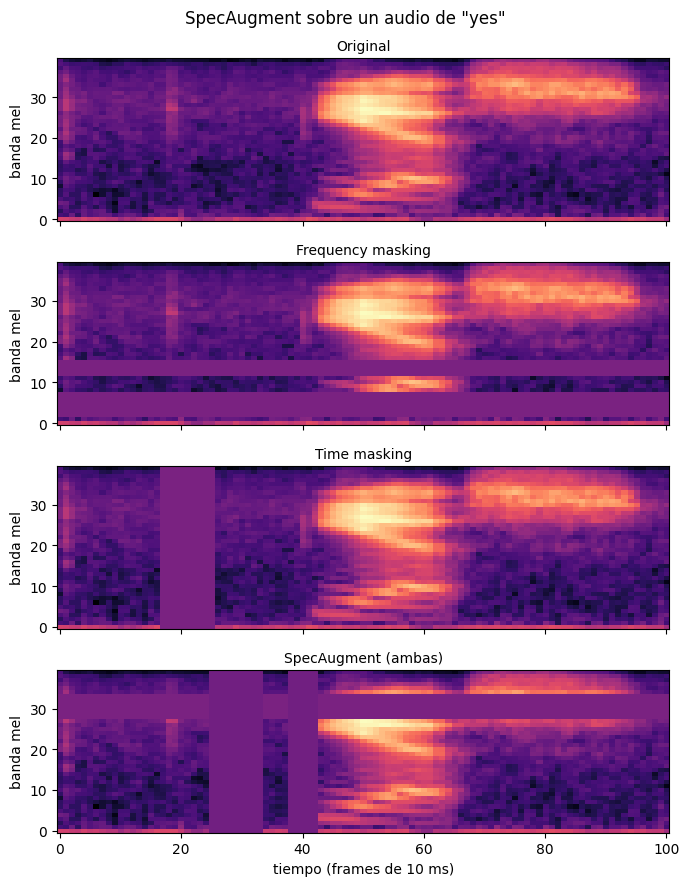

In [29]:
X_aug, y_aug = aug_train
n = len(raw["train"][1])

assert len(y_aug) == 2 * n
assert torch.equal(X_aug[:n], raw["train"][0]), "los originales deben quedar intactos"
assert torch.equal(y_aug[n:], raw["train"][1]), "cada copia conserva su etiqueta"
for s in ["val", "test"]:
    assert torch.equal(DATASETS["aumentado"][s].X, DATASETS["crudo"][s].X)
cambiados = (X_aug[n:] != X_aug[:n]).flatten(1).any(dim=1).float().mean().item()
print(f"Copias distintas de su original: {100 * cambiados:.1f} %")

# Figura: original, solo frecuencia, solo tiempo, SpecAugment completo
set_seed()
i = raw["train"][1].tolist().index(LABEL_TO_IDX["yes"])
original = raw["train"][0][i]
versiones = {"Original": original, "Frequency masking": freq_mask(original),
             "Time masking": time_mask(original), "SpecAugment (ambas)": spec_augment(original)}

fig, axes = plt.subplots(4, 1, figsize=(7, 9), sharex=True)
for ax, (titulo, img) in zip(axes, versiones.items()):
    ax.imshow(img, origin="lower", aspect="auto", cmap="magma", vmin=original.min(), vmax=original.max())
    ax.set_title(titulo, fontsize=10); ax.set_ylabel("banda mel")
axes[-1].set_xlabel("tiempo (frames de 10 ms)")
fig.suptitle('SpecAugment sobre un audio de "yes"')
fig.tight_layout(); fig.savefig(OUT_DIR / "ejemplos_aumentacion.png", dpi=150); plt.show()
set_seed()   # dejar las semillas como al inicio para las fases siguientes

## 2. Arquitecturas de los modelos



### 2.1 Modelo A: LeNet-5

El enunciado pide una **variante clásica de LeNet-5** (LeCun et al., 1998) adaptada a espectrogramas. Solo se permite cambiar el **tamaño de entrada**, el **número de canales** y los **hiperparámetros**; cualquier otro cambio debe consultarse con el profesor y justificarse.

**LeNet-5 original** (entrada: imagen de 32 × 32, un canal):

| Capa | Tipo | Configuración | Salida |
|---|---|---|---|
| Entrada | — | imagen en escala de grises | 1 × 32 × 32 |
| C1 | Convolución + tanh | 6 filtros de 5 × 5 | 6 × 28 × 28 |
| S2 | Submuestreo | 2 × 2, paso 2 | 6 × 14 × 14 |
| C3 | Convolución + tanh | 16 filtros de 5 × 5 | 16 × 10 × 10 |
| S4 | Submuestreo | 2 × 2, paso 2 | 16 × 5 × 5 |
| C5 | Convolución + tanh | 120 filtros de 5 × 5 (cubren todo S4) | 120 × 1 × 1 |
| F6 | Totalmente conectada + tanh | 84 neuronas | 84 |
| Salida | — | 10 clases (dígitos) | 10 |

**Modelo A** (entrada: espectrograma de 40 × 101, un canal):

| Capa | Tipo | Configuración | Salida |
|---|---|---|---|
| Entrada | — | log-mel: 40 bandas × 101 frames, normalizado | 1 × 40 × 101 |
| C1 | `Conv2d` + `Tanh` | 6 filtros de 5 × 5 | 6 × 36 × 97 |
| S2 | `AvgPool2d` | 2 × 2, paso 2 | 6 × 18 × 48 |
| C3 | `Conv2d` + `Tanh` | 16 filtros de 5 × 5 | 16 × 14 × 44 |
| S4 | `AvgPool2d` | 2 × 2, paso 2 | 16 × 7 × 22 |
| C5 | `Conv2d` + `Tanh` | 120 filtros de **7 × 22** (cubren todo S4) | 120 × 1 × 1 |
| F6 | `Linear` + `Tanh` | 84 neuronas | 84 |
| Salida | `Linear` | 10 clases (comandos) | 10 |

Se conservan el número de capas, su orden, el tipo de cada una, los filtros de 5 × 5 en C1 y C3, los anchos (6, 16, 120, 84), la activación tanh y el submuestreo promedio de 2 × 2.

**Cambios permitidos por el enunciado:**

1. **Tamaño de entrada: 32 × 32 → 40 × 101.** Es el tamaño del espectrograma definido en el contrato de entrada (40 bandas mel × 101 frames de 10 ms). No se redimensiona a 32 × 32 porque se perdería resolución en el tiempo (101 → 32 frames) y la app tendría que repetir ese paso.
2. **Kernel de C5: 5 × 5 → 7 × 22.** Es consecuencia directa del cambio anterior. En el original, C5 usa filtros del mismo tamaño que el mapa de S4 (5 × 5), así cada una de sus 120 neuronas ve todo S4. Con la nueva entrada, S4 mide 7 × 22, así que C5 usa filtros de 7 × 22 para cumplir el mismo papel.
3. **Canales de entrada: 1.** Igual que el original: un espectrograma tiene un solo canal, como una imagen en escala de grises.
4. **Salida: 10 clases.** Igual número que el original; aquí son los 10 comandos en lugar de los 10 dígitos.

**Normalización de la entrada.** LeCun et al. normalizaban la entrada para que tuviera media cercana a 0 y varianza cercana a 1, lo que acelera el aprendizaje con tanh. Aquí se hace lo mismo con `(x - MEDIA) / DESV`, usando la misma media y desviación global del entrenamiento crudo que el Modelo B (sección 2.3). Igual que en el Modelo B, son *buffers* dentro del modelo: no se entrenan, se guardan con los pesos y viajan en el `.onnx`. No es una capa nueva, es el preprocesamiento de la entrada.

**Función de pérdida y optimizador.** Se usan las rutinas comunes de la sección 2.3 (`fit`), iguales para los dos modelos: entropía cruzada como pérdida y Adam (o SGD con momento) como optimizador. La entropía cruzada reemplaza al criterio basado en las unidades RBF del artículo, y Adam reemplaza al descenso de gradiente con ajustes de segundo orden que usaba el artículo, que no existe en PyTorch. La tasa de aprendizaje y el resto de los valores son hiperparámetros de cada configuración (Fase 3).

**Diferencias con el artículo de 1998 que hay que confirmar con el profesor.** Son las simplificaciones que usan las implementaciones habituales de la "LeNet-5 clásica"; se listan para consultarlas, como pide el enunciado:

| Artículo original | Modelo A | Motivo |
|---|---|---|
| S2 y S4: suma de 2 × 2 por un coeficiente entrenable, más sesgo y sigmoide | `AvgPool2d` sin parámetros | Cumple la misma función (reducir a la mitad el tamaño promediando vecinos) y es la forma estándar en PyTorch |
| C3: tabla de conexiones parcial (cada mapa de C3 ve solo algunos mapas de S2) | Cada mapa de C3 ve los 6 mapas de S2 | La tabla parcial se usó en 1998 para reducir cálculo; hoy ese costo es despreciable |
| Activación: tanh escalada, 1.7159 · tanh(2x/3) | `nn.Tanh` estándar | Mismo tipo de activación; el escalado era un detalle de inicialización de la época |
| Salida: unidades RBF (distancia euclídea a prototipos) | `Linear` con 10 salidas + softmax en la pérdida | Las RBF se diseñaron para dígitos con prototipos dibujados a mano; no existen prototipos equivalentes para comandos de voz |

In [30]:
from torch import nn

class ModeloA(nn.Module):
    """LeNet-5 clásica adaptada a espectrogramas. Entrada (N, 1, 40, 101) log-mel SIN normalizar; salida (N, 10) logits."""

    def __init__(self, num_classes=len(COMMANDS), media=0.0, desv=1.0):
        super().__init__()
        # Normalización de la entrada como buffers (igual que el Modelo B): no se entrenan y viajan en el .onnx
        self.register_buffer("media", torch.tensor(float(media)))
        self.register_buffer("desv", torch.tensor(float(desv)))

        # Tamaño del mapa después de S4: cada conv 5×5 resta 4 y cada submuestreo 2×2 divide entre 2
        alto  = ((N_MELS - 4) // 2 - 4) // 2      # 40  → 7
        ancho = ((N_FRAMES - 4) // 2 - 4) // 2    # 101 → 22

        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),                 # C1
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),          # S2
            nn.Conv2d(6, 16, kernel_size=5),                # C3
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),          # S4
            nn.Conv2d(16, 120, kernel_size=(alto, ancho)),  # C5: cubre todo el mapa de S4
            nn.Tanh(),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(120, 84),                             # F6
            nn.Tanh(),
            nn.Linear(84, num_classes),                     # Salida
        )

    def forward(self, x):          # x: (N, 1, 40, 101)
        x = (x - self.media) / self.desv
        return self.classifier(self.features(x))   # (N, 10)

**Verificación.** Se pasa un lote real del dataset crudo por el modelo y se imprime la forma de la salida de cada capa, para confirmar que coincide con la tabla de arriba.

In [31]:
set_seed()
x = raw["train"][0][:8].unsqueeze(1)   # 8 espectrogramas: (8, 1, 40, 101)
h = x
print(f"{'Entrada':<8} {tuple(x.shape)}")
for nombre, capa in zip(["C1", "", "S2", "C3", "", "S4", "C5", ""], ModeloA().features):
    h = capa(h)
    if nombre:
        print(f"{nombre:<8} {tuple(h.shape)}")
print(f"{'Salida':<8} {tuple(ModeloA()(x).shape)}")

Entrada  (8, 1, 40, 101)
C1       (8, 6, 36, 97)
S2       (8, 6, 18, 48)
C3       (8, 16, 14, 44)
S4       (8, 16, 7, 22)
C5       (8, 120, 1, 1)
Salida   (8, 10)


### 2.2 Modelo B: MobileNetV2 reducido

Arquitectura ligera pensada para el celular, basada en MobileNetV2, reducida para un espectrograma de 40 × 101 y 10 clases con `torch.nn`.

**Bloque base (residual invertido):** convolución 1×1 de expansión -> convolución 3×3 por canal (*depthwise*) -> convolución 1×1 de proyección **lineal** (sin activación).

| Etapa | Salida (canales, bandas, frames) | Detalle |
|---|---|---|
| Entrada | 1, 40, 101 | log-mel normalizado dentro del modelo |
| Stem | 16, 20, 51 | conv 3×3, stride 2, BN, ReLU6 |
| Bloque 1 | 16, 20, 51 | expansión 1 |
| Bloques 2-3 | 24, 10, 26 | expansión 4, stride 2 en el primero |
| Bloques 4-5 | 32, 5, 13 | expansión 4, stride 2 en el primero |
| Bloque 6 | 64, 5, 13 | expansión 4 |
| Cabeza | 128, 5, 13 | conv 1×1, BN, ReLU6 |
| Salida | 10 | promedio global, dropout, capa lineal |


- Separar la convolución en *depthwise* 3×3 y *pointwise* 1×1 reduce el costo de cálculo frente a una convolución 3×3 completa, con ligera pérdida de exactitud.

- La proyección sin activación evita destruir información en pocos canales, y el atajo facilita el flujo del gradiente.

- Seis bloques con 16, 24, 32 y 64 canales bastan para 10 clases sobre 40 × 101. El campo receptivo abarca todo el eje de frecuencia.

- ReLU6 acota la activación en [0, 6], lo que conserva precisión para luego cuantizar el modelo, y exportar ONNX.

- BatchNorm y convoluciones sin sesgo ya que es redundante antes de BN.

- Regularización de promedio global con menos parametros en lugar de capas densas grandes, dropout antes de la capa final y decaimiento de pesos opcional.

- `(x - MEDIA) / DESV` es la primera operación y sus constantes son buffers, así que viajan en el `.onnx` y la app no la reimplementa.

In [32]:
from torch import nn

NUM_CLASSES = 10
INPUT_SHAPE = (1, N_MELS, N_FRAMES)   # (canal, bandas, frames), del contrato de entrada


class ConvBNAct(nn.Sequential):
    #Conv2d (sin sesgo) + BatchNorm2d + ReLU6.
    def __init__(self, c_in, c_out, kernel=3, stride=1, groups=1):
        super().__init__(
            nn.Conv2d(c_in, c_out, kernel, stride, kernel // 2, groups=groups, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU6(inplace=True),
        )

class InvertedResidual(nn.Module):
    #Expansión 1x1 -> depthwise 3x3 -> proyección 1x1 lineal, con atajo si stride=1 y c_in=c_out.
    def __init__(self, c_in, c_out, stride, expand):
        super().__init__()
        hidden = c_in * expand
        layers = []
        if expand != 1:
            layers.append(ConvBNAct(c_in, hidden, kernel=1))            # expansión
        layers.append(ConvBNAct(hidden, hidden, kernel=3, stride=stride, groups=hidden)) # depthwise
        layers += [nn.Conv2d(hidden, c_out, 1, bias=False), nn.BatchNorm2d(c_out)] # proyección lineal
        self.block = nn.Sequential(*layers)
        self.use_res = stride == 1 and c_in == c_out

    def forward(self, x):
        out = self.block(x)
        return x + out if self.use_res else out

STEM_CHANNELS = 16
# (expansión t, canales de salida, repeticiones n, stride s del primer bloque)
SETTINGS = [(1, 16, 1, 1), (4, 24, 2, 2), (4, 32, 2, 2), (4, 64, 1, 1)]
HEAD_CHANNELS = 128

class ModeloB(nn.Module):
    #MobileNetV2 reducido. Entrada (N, 1, 40, 101) log-mel SIN normalizar; salida (N, 10) logits.
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.2, media=0.0, desv=1.0):
        super().__init__()
        # Normalización global como buffers: no se entrenan, pero se guardan y viajan en el .onnx
        self.register_buffer("media", torch.tensor(float(media)))
        self.register_buffer("desv", torch.tensor(float(desv)))

        c = STEM_CHANNELS
        layers = [ConvBNAct(1, c, kernel=3, stride=2)]   # 40x101 -> 20x51
        for t, c_out, n_rep, s in SETTINGS:
            for k in range(n_rep):
                layers.append(InvertedResidual(c, c_out, s if k == 0 else 1, t))
                c = c_out
        layers.append(ConvBNAct(c, HEAD_CHANNELS, kernel=1))
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(HEAD_CHANNELS, num_classes)

        for m in self.modules():   # inicialización
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def forward(self, x):
        if not torch.jit.is_tracing() and (x.dim() != 4 or tuple(x.shape[1:]) != INPUT_SHAPE):
            raise ValueError(f"Se esperaba (N, 1, {N_MELS}, {N_FRAMES}), llegó {tuple(x.shape)}")
        x = (x - self.media) / self.desv
        x = self.pool(self.features(x)).flatten(1)
        return self.fc(self.dropout(x))

#!  Conteo de parámetros, MACs y campo receptivo (sirve también para el Modelo A) !!!!
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    return {"total": total, "tamano_fp32_kb": total * 4 / 1024}

@torch.no_grad()
def count_macs(model, input_shape=(1, 1, N_MELS, N_FRAMES)):
    #MACs de Conv2d y Linear para UNA muestra (BN, activaciones y pooling se ignoran).
    filas, hooks = [], []
    def conv_hook(nombre):
        def f(m, inp, out):
            k = m.kernel_size[0] * m.kernel_size[1]
            filas.append((nombre, "Conv2d", tuple(out.shape[1:]), out.numel() // out.shape[0] * (m.in_channels // m.groups) * k))
        return f
    def linear_hook(nombre):
        def f(m, inp, out):
            filas.append((nombre, "Linear", tuple(out.shape[1:]), m.in_features * m.out_features))
        return f
    for nombre, m in model.named_modules():
        if isinstance(m, nn.Conv2d): hooks.append(m.register_forward_hook(conv_hook(nombre)))
        elif isinstance(m, nn.Linear): hooks.append(m.register_forward_hook(linear_hook(nombre)))
    estaba_entrenando = model.training
    model.eval()
    model(torch.zeros(input_shape, device=next(model.parameters()).device))
    model.train(estaba_entrenando)
    for h in hooks: h.remove()
    return {"total": sum(f[3] for f in filas), "capas": filas}

def receptive_field(model):
    #Campo receptivo (bandas, frames) del último mapa convolucional, para cadenas secuenciales de Conv2d.
    rf, salto = [1, 1], [1, 1]
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            for ax in range(2):
                rf[ax] += m.dilation[ax] * (m.kernel_size[ax] - 1) * salto[ax]
                salto[ax] *= m.stride[ax]
    return {"bandas": rf[0], "frames": rf[1]}

def resumen_modelo(model):
    p, m, rf = count_params(model), count_macs(model), receptive_field(model)
    lineas = [f"Parámetros: {p['total']:,} (~{p['tamano_fp32_kb']:.0f} KB en fp32)",
              f"MACs por muestra: {m['total']:,} (~{m['total'] / 1e6:.2f} M)",
              f"Campo receptivo: {rf['bandas']} bandas x {rf['frames']} frames", "",
              f"{'capa':<26}{'tipo':<8}{'salida':<18}{'MACs':>12}"]
    lineas += [f"{n:<26}{t:<8}{str(s):<18}{mac:>12,}" for n, t, s, mac in m["capas"]]
    return "\n".join(lineas)

print(resumen_modelo(ModeloB()))

Parámetros: 50,410 (~197 KB en fp32)
MACs por muestra: 6,440,800 (~6.44 M)
Campo receptivo: 59 bandas x 59 frames

capa                      tipo    salida                    MACs
features.0.0              Conv2d  (16, 20, 51)           146,880
features.1.block.0.0      Conv2d  (16, 20, 51)           146,880
features.1.block.1        Conv2d  (16, 20, 51)           261,120
features.2.block.0.0      Conv2d  (64, 20, 51)         1,044,480
features.2.block.1.0      Conv2d  (64, 10, 26)           149,760
features.2.block.2        Conv2d  (24, 10, 26)           399,360
features.3.block.0.0      Conv2d  (96, 10, 26)           599,040
features.3.block.1.0      Conv2d  (96, 10, 26)           224,640
features.3.block.2        Conv2d  (24, 10, 26)           599,040
features.4.block.0.0      Conv2d  (96, 10, 26)           599,040
features.4.block.1.0      Conv2d  (96, 5, 13)             56,160
features.4.block.2        Conv2d  (32, 5, 13)            199,680
features.5.block.0.0      Conv2d  (128, 

### 2.3 Rutinas de entrenamiento, validación y prueba

Comunes a los dos modelos, para que los 12 entrenamientos se hagan igual y solo cambien los hiperparámetros.

- `fit` recibe los tensores `X` de forma `(N, 40, 101)` y `y`. Con `DATASETS[...]["train"].X` y `.y` se entrena con el dataset crudo o con el aumentado
- `MEDIA` y `DESV` se calculan una sola vez con el entrenamiento **crudo** y se usan igual en los dos datasets, para que la comparación sea justa.
- Entropía cruzada; Adam o SGD con momento de Nesterov, con decaimiento coseno de la tasa de aprendizaje.
- Se queda con la época de mayor F1 macro en validación. La prueba no interviene en `fit`.
- Checkpoints: `<run>_best.pt` y `<run>_last.pt` en `CKPT_DIR`. Con `resume=True` retoma desde `_last.pt`.
- W&B: si se pasa `run`, registra `train/loss`, `train/accuracy`, `val/loss`, `val/accuracy`, `val/f1_macro` y la matriz de confusión.

In [33]:
from torch.utils.data import DataLoader, TensorDataset

CKPT_DIR = (Path("/content/drive/MyDrive/ProyectoIA_ComandosDeVoz/checkpoints") if IN_COLAB
            else OUT_DIR / "checkpoints")   # en escritorio queda dentro del repo: no subir los .pt a git
CKPT_DIR.mkdir(parents=True, exist_ok=True)

def compute_normalization(X_train):
    #MEDIA y DESV globales. Llamar SOLO con el entrenamiento crudo.
    return float(X_train.mean()), float(X_train.std())

def make_loader(X, y, batch_size, shuffle, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle,
                      generator=g if shuffle else None)

def confusion_matrix(y_true, y_pred, n_clases=len(COMMANDS)):
    cm = np.zeros((n_clases, n_clases), dtype=np.int64)
    np.add.at(cm, (y_true, y_pred), 1)
    return cm   # filas = real, columnas = predicho

def metrics_from_confusion(cm):
    tp = np.diag(cm).astype(float)
    precision = tp / np.maximum(cm.sum(0), 1)
    recall = tp / np.maximum(cm.sum(1), 1)
    f1 = np.where(precision + recall > 0, 2 * precision * recall / np.maximum(precision + recall, 1e-12), 0.0)
    return {"accuracy": float(tp.sum() / max(cm.sum(), 1)), "f1_macro": float(f1.mean()),
            "f1_por_clase": {c: float(v) for c, v in zip(COMMANDS, f1)}}

@torch.no_grad()
def evaluate(model, loader, device, criterion=None):
    #Evalúa (sin dropout ni BN en entrenamiento). Devuelve loss, accuracy, f1_macro, y_true y y_pred.
    model.eval()
    perdida, n_total, ys, ps = 0.0, 0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        salida = model(xb.unsqueeze(1))
        if criterion is not None:
            perdida += criterion(salida, yb).item() * len(yb)
        n_total += len(yb)
        ys.append(yb.cpu()); ps.append(salida.argmax(1).cpu())
    y_true, y_pred = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    res = metrics_from_confusion(confusion_matrix(y_true, y_pred))
    res.update(loss=perdida / max(n_total, 1) if criterion is not None else float("nan"),
               y_true=y_true, y_pred=y_pred)
    return res

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    perdida, aciertos, n_total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        salida = model(xb.unsqueeze(1))   # (B, 40, 101) -> (B, 1, 40, 101)
        loss = criterion(salida, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        perdida += loss.item() * len(yb)
        aciertos += (salida.argmax(1) == yb).sum().item()
        n_total += len(yb)
    return {"loss": perdida / n_total, "accuracy": aciertos / n_total}

def _guardar_atomico(obj, ruta):
    #Guarda en un archivo temporal y lo renombra: un corte de Colab no deja checkpoints a medias.
    ruta = Path(ruta)
    ruta.parent.mkdir(parents=True, exist_ok=True)
    tmp = ruta.with_suffix(ruta.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, ruta)

def fit(model, X_train, y_train, X_val, y_val, *, epochs, lr, batch_size, weight_decay=0.0,
        optimizer_name="adam", seed=SEED, device=None, ckpt_dir=None, run_name="modeloB",
        run=None, resume=False, verbose=True):
    #Entrena y valida; deja el modelo en su mejor época (mayor F1 macro de validación).
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    set_seed(seed)
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    else:
        raise ValueError(f"optimizador desconocido: {optimizer_name}")
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_loader = make_loader(X_train, y_train, batch_size, True, seed)
    val_loader = make_loader(X_val, y_val, batch_size * 2, False)

    hist = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "val_f1"]}
    best_f1, best_epoch, inicio = -1.0, 0, 1
    last_path = Path(ckpt_dir) / f"{run_name}_last.pt" if ckpt_dir else None
    best_path = Path(ckpt_dir) / f"{run_name}_best.pt" if ckpt_dir else None

    if resume and last_path is not None and last_path.exists():
        ck = torch.load(last_path, map_location=device, weights_only=False)
        model.load_state_dict(ck["model"]); optimizer.load_state_dict(ck["optimizer"])
        scheduler.load_state_dict(ck["scheduler"])
        hist, best_f1, best_epoch, inicio = ck["hist"], ck["best_f1"], ck["best_epoch"], ck["epoch"] + 1
        if verbose: print(f"Reanudando desde la época {inicio}")

    for epoch in range(inicio, epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va = evaluate(model, val_loader, device, criterion)
        scheduler.step()
        for k, v in zip(hist, [tr["loss"], tr["accuracy"], va["loss"], va["accuracy"], va["f1_macro"]]):
            hist[k].append(v)
        if run is not None:
            run.log({"epoch": epoch, "train/loss": tr["loss"], "train/accuracy": tr["accuracy"],
                     "val/loss": va["loss"], "val/accuracy": va["accuracy"],
                     "val/f1_macro": va["f1_macro"], "lr": scheduler.get_last_lr()[0]})
        if va["f1_macro"] > best_f1:
            best_f1, best_epoch = va["f1_macro"], epoch
            if best_path is not None:
                _guardar_atomico({"model": model.state_dict(), "epoch": epoch, "val_f1": best_f1}, best_path)
        if last_path is not None:
            _guardar_atomico({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                              "scheduler": scheduler.state_dict(), "hist": hist, "best_f1": best_f1,
                              "best_epoch": best_epoch, "epoch": epoch}, last_path)
        if verbose:
            print(f"ép {epoch:3d}/{epochs} | train {tr['loss']:.3f}/{tr['accuracy']:.3f} | "
                  f"val {va['loss']:.3f}/{va['accuracy']:.3f} | F1 {va['f1_macro']:.3f}")

    if best_path is not None and best_path.exists():
        model.load_state_dict(torch.load(best_path, map_location=device)["model"])
    if run is not None:
        import wandb
        va = evaluate(model, val_loader, device, criterion)
        run.log({"val/confusion_matrix": wandb.plot.confusion_matrix(
            y_true=va["y_true"].tolist(), preds=va["y_pred"].tolist(), class_names=COMMANDS)})
        run.summary["mejor_val_f1"] = best_f1
        run.summary["mejor_epoca"] = best_epoch
    return {"hist": hist, "best_f1": best_f1, "best_epoch": best_epoch}

In [34]:
#Normalizacion global de los espectrogramas
Xtr_raw, ytr_raw = raw["train"]
media, desv = compute_normalization(Xtr_raw)   # solo entrenamiento crudo, igual para crudo y aumentado

In [35]:
# Prueba: 3 épocas sobre 3000 espectrogramas aleatorios del entrenamiento crudo.

print(f"MEDIA = {media:.4f} | DESV = {desv:.4f}")

idx = torch.randperm(len(ytr_raw), generator=torch.Generator().manual_seed(SEED))[:3000]
set_seed()
modelo_prueba = ModeloB(media=media, desv=desv)
_ = fit(modelo_prueba, Xtr_raw[idx], ytr_raw[idx], *raw["val"], epochs=3, lr=1e-3, batch_size=64)

MEDIA = -6.5107 | DESV = 4.8010
ép   1/3 | train 2.256/0.183 | val 2.260/0.137 | F1 0.055
ép   2/3 | train 1.899/0.340 | val 1.662/0.357 | F1 0.260
ép   3/3 | train 1.580/0.426 | val 1.578/0.430 | F1 0.345


In [36]:
# Prueba del Modelo A con las mismas rutinas y los mismos datos que la prueba del Modelo B
print(resumen_modelo(ModeloA()).split("\n\n")[0])   # parámetros, MACs y campo receptivo
set_seed()
modelo_prueba_A = ModeloA(media=media, desv=desv)
_ = fit(modelo_prueba_A, Xtr_raw[idx], ytr_raw[idx], *raw["val"], epochs=3, lr=1e-3, batch_size=64, run_name="modeloA")

Parámetros: 309,386 (~1209 KB en fp32)
MACs por muestra: 2,308,800 (~2.31 M)
Campo receptivo: 15 bandas x 30 frames
ép   1/3 | train 2.066/0.260 | val 1.788/0.410 | F1 0.385
ép   2/3 | train 1.638/0.438 | val 1.563/0.476 | F1 0.457
ép   3/3 | train 1.449/0.524 | val 1.486/0.515 | F1 0.505
